In [14]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
import os
import random
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [1]:
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    
seed_everything(7)

NameError: name 'random' is not defined

In [3]:
folder_dir = os.path.expanduser("~/cps_persistent1_shared/datasets/puneeth/ICPS_data")

dfs = []
class_names = []
minerals = ['Albit', 'Amazonit', 'Anorthosit', 'Biotit', 'Calcite', 'Dolomit', 'Feldspat','Kaolinit', 'Muscovit', 'Orthoclase', 'Quarz', 'Rhodochrosite']
for mineral_name in os.listdir(folder_dir):
    mineral_path = os.path.join(folder_dir, mineral_name)
    
    if os.path.isdir(mineral_path) and mineral_name in minerals:
        file_path = os.path.join(mineral_path, "30fps", "profiles.csv")
        
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, header=None, decimal=',')
            
            # Select every 6th row starting from Row 3
            # Select columns from index 0 to -1 (Ignore  last column)
            df_numeric = df.iloc[3::6, :-1].astype(np.float32) #Why 1st column?
            print(df.head())
            print(df_numeric.head())
            dfs.append(df_numeric)
            class_names.append(mineral_name)
            
print(class_names)

     0       1       2       3       4       5       6       7       8     \
0    0.00    1.00    2.00    3.00    4.00    5.00    6.00    7.00    8.00   
1    1.00    2.00    3.00    4.00    5.00    6.00    7.00    8.00    9.00   
2  137.00  140.00  143.00  146.00  150.00  153.00  156.00  159.00  162.00   
3    0.66    0.66    0.66    0.66    0.66    0.66    0.66    0.65    0.65   
4    0.66    0.66    0.66    0.66    0.66    0.66    0.66    0.65    0.65   

     9     ...     1051     1052     1053     1054     1055     1056     1057  \
0    9.00  ...  1051.00  1052.00  1053.00  1054.00  1055.00  1056.00  1057.00   
1   10.00  ...  1052.00  1053.00  1054.00  1055.00  1056.00  1057.00  1058.00   
2  165.00  ...  3448.00  3451.00  3455.00  3458.00  3461.00  3464.00  3467.00   
3    0.65  ...     0.86     0.85     0.83     0.82     0.81     0.79     0.78   
4    0.65  ...     0.86     0.85     0.83     0.82     0.81     0.79     0.78   

      1058     1059                               

In [9]:
dfs[0]

,0,1,2,3,4,5,6,7,8,9,...,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059
3,0.66,0.66,0.66,0.66,0.66,0.66,0.66,0.65,0.65,0.65,...,0.87,0.86,0.85,0.83,0.82,0.81,0.79,0.78,0.77,0.76
9,0.64,0.64,0.65,0.65,0.66,0.67,0.67,0.68,0.68,0.69,...,2.08,2.06,2.05,2.03,2.02,2.01,2.00,1.99,1.98,1.97
15,0.55,0.55,0.56,0.56,0.56,0.56,0.57,0.57,0.57,0.58,...,1.01,1.01,1.01,1.02,1.02,1.02,1.03,1.03,1.03,1.04
21,1.23,1.24,1.26,1.27,1.28,1.30,1.31,1.33,1.34,1.36,...,2.96,2.94,2.93,2.91,2.89,2.88,2.86,2.85,2.84,2.82
27,0.73,0.73,0.73,0.74,0.74,0.74,0.75,0.75,0.75,0.76,...,2.18,2.16,2.15,2.14,2.13,2.12,2.11,2.10,2.10,2.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15075,0.70,0.70,0.70,0.71,0.71,0.71,0.72,0.72,0.72,0.73,...,1.06,1.05,1.04,1.03,1.02,1.02,1.01,1.00,1.00,0.99
15081,0.71,0.72,0.73,0.73,0.74,0.75,0.76,0.77,0.78,0.78,...,2.26,2.25,2.24,2.23,2.22,2.21,2.20,2.20,2.19,2.18
15087,0.58,0.59,0.60,0.60,0.61,0.62,0.62,0.63,0.64,0.65,...,2.25,2.24,2.24,2.24,2.24,2.24,2.24,2.24,2.24,2.24
15093,0.91,0.93,0.95,0.97,0.99,1.01,1.03,1.05,1.07,1.09,...,3.13,3.11,3.09,3.08,3.06,3.04,3.03,3.01,3.00,2.98


In [4]:
class_names

['Orthoclase',
 'Biotit',
 'Anorthosit',
 'Quarz',
 'Kaolinit',
 'Albit',
 'Amazonit',
 'Feldspat',
 'Dolomit',
 'Calcite',
 'Muscovit',
 'Rhodochrosite']

In [5]:
# adding labels in a new column at -1

dataset = []
for i, d in enumerate(dfs):
    class_num =  np.array([i] * d.shape[0], dtype=np.float32)
    d = np.c_[d, class_num] # concatenate along 2nd axis
    # print(d.shape, class_num.shape)
    dataset.extend(d) #[:5000])
dataset = np.array(dataset)
dataset

array([[ 0.66,  0.66,  0.66, ...,  0.77,  0.76,  0.  ],
       [ 0.64,  0.64,  0.65, ...,  1.98,  1.97,  0.  ],
       [ 0.55,  0.55,  0.56, ...,  1.03,  1.04,  0.  ],
       ...,
       [12.81, 13.  , 13.2 , ..., 17.15, 17.09, 11.  ],
       [ 1.4 ,  1.41,  1.42, ...,  8.  ,  7.99, 11.  ],
       [ 0.92,  0.92,  0.93, ...,  6.29,  6.26, 11.  ]],
      shape=(34526, 1061), dtype=float32)

In [6]:
X = dataset[:, :-1]
y = dataset[:, -1:]
X.shape, X[0, -5:], y.shape, np.unique(y)

((34526, 1060),
 array([0.81, 0.79, 0.78, 0.77, 0.76], dtype=float32),
 (34526, 1),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.],
       dtype=float32))

In [7]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=3)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((27620, 1060), (6906, 1060), (27620, 1), (6906, 1))

In [8]:
class RockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
    def __len__(self):
        return len(self.X)

train_dataset = RockDataset(X_train, y_train)
test_dataset = RockDataset(X_test, y_test)

In [9]:
import itertools

# Define lists for each hyperparameter
batch_sizes = [2048]
lrs = [0.0001, 0.00001]
epochs_list = [50]
weight_decays = [0., 1e-4]

# Generate all combinations
hyperparameters_list = []
for batch_size, lr, epochs, weight_decay in itertools.product(batch_sizes, lrs, epochs_list, weight_decays):
    hyperparameters_list.append({
        'batch_size': batch_size,
        'lr': lr,
        'epochs': epochs,
        'weight_decay': weight_decay
    })

print(f"Generated {len(hyperparameters_list)} combinations.")

Generated 4 combinations.


In [10]:
# we use 1d cnn instead of a mlp because it can work on any input series size
# using layer norm on the input directly increases performance at the cost of our input series dimension being fixed
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm_input = nn.LayerNorm(normalized_shape=1060)
        self.conv1 = nn.Conv1d(1, 16, kernel_size=9, stride=3)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=9, stride=3)
        self.layer_norm_1 = nn.LayerNorm(normalized_shape=32)
        self.fnn1 = nn.Linear(32, len(class_names))
    
        self.relu = nn.ReLU()
        self.max_pool = nn.MaxPool1d(kernel_size=2)
        self.global_pool = nn.AdaptiveMaxPool1d(output_size=1)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p=0.2)
        
    def forward(self, x):
        x = self.layer_norm_input(x)
        x = x.unsqueeze(1)
        x = self.relu(self.conv1(x))
        x = self.max_pool(x)
        x = self.relu(self.conv2(x))
        x = self.global_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.layer_norm_1(x)
        x = self.fnn1(x)
        return x
    
model = Model()
sum(p.numel() for p in model.parameters())

7380

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import json
import numpy as np

experiment_results = []

# Select 4 fixed profiles from test set for monitoring
monitor_indices = np.arange(4)

# Prepare them as tensors once
X_monitor = torch.from_numpy(X_test[monitor_indices])
y_monitor = torch.from_numpy(y_test[monitor_indices]).squeeze().long()

print(f"Selected Monitor Indices: {monitor_indices}")
print(f"Monitor True Labels: {[class_names[int(i)] for i in y_monitor]}")

for idx, config in enumerate(hyperparameters_list):
    print(f"\n{'='*20}\nStarting Experiment {idx+1}\nConfig: {config}\n{'='*20}")
    config_number = idx
    # Setup Loaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, num_workers=32)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=8)
    
    # Setup Model & Optimizer
    model = Model()
    optimizer = torch.optim.Adam(params=model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.CrossEntropyLoss()

    # Initialize "Best" tracking for this specific experiment
    best_accuracy = 0.0
    best_model_path = f"best_model_exp_{idx+1}.pth"
    
    # Training Lists
    training_loss = []
    training_acc = []
    testing_loss = []
    testing_acc = []
    
    # for epoch in range(config['epochs']):
    #     avg_train_loss = []
    #     avg_train_acc = []
    #     avg_test_loss = []
    #     avg_test_acc = []
        
    #     print(f"Epoch: {epoch + 1}/{config['epochs']}")
        
    #     # Train
    #     model.train()
    #     for i, d in tqdm(enumerate(train_loader), total=len(train_loader), leave=False):
    #         X, y = d
    #         y = y.squeeze().long()
    #         optimizer.zero_grad()
    #         outputs = model(X)
    #         loss = criterion(outputs, y)
    #         loss.backward()
    #         optimizer.step()
                    
    #         _, predicted_labels = torch.max(outputs, 1)
    #         correct_predictions = (predicted_labels == y).sum().item()
    #         total_samples = y.size(0)
    #         accuracy = correct_predictions / total_samples
            
    #         avg_train_loss.append(loss.item())
    #         avg_train_acc.append(accuracy)
            
    #     avg_acc_train = sum(avg_train_acc)/len(avg_train_acc)
    #     avg_loss_train = sum(avg_train_loss)/len(avg_train_loss)
    #     training_acc.append(avg_acc_train)
    #     training_loss.append(avg_loss_train)
    #     print(f"Training: Loss={avg_loss_train:.4f}, Acc={avg_acc_train:.4f}")
        
    #     # Test
    #     model.eval()
    #     all_preds, all_true = [], [] # Re-init for CM on last epoch
    #     with torch.no_grad():
    #         for i, d in tqdm(enumerate(test_loader), total=len(test_loader), leave=False):
    #             X, y = d
    #             y = y.squeeze().long()
    #             outputs = model(X)
    #             loss = criterion(outputs, y)
                    
    #             preds = torch.max(outputs, 1)[1]
    #             all_preds.extend(preds.cpu().numpy())
    #             all_true.extend(y.cpu().numpy())
                
    #             acc = (preds == y).sum().item() / y.size(0)
    #             avg_test_loss.append(loss.item())
    #             avg_test_acc.append(acc)
                
    #     avg_acc_test = sum(avg_test_acc)/len(avg_test_acc)
    #     avg_loss_test = sum(avg_test_loss)/len(avg_test_loss)
    #     testing_acc.append(avg_acc_test)
    #     testing_loss.append(avg_loss_test)
    #     print(f"Testing: Loss={avg_loss_test:.4f}, Acc={avg_acc_test:.4f}\n")

    #     if avg_acc_test > best_accuracy:
    #         best_accuracy = avg_acc_test
    #         #Save model
    #         if not os.path.exists('1d_cnn_results'):
    #             os.mkdir('1d_cnn_results')
    #         torch.save(model.state_dict(), os.path.join('1d_cnn_results',best_model_path))
    #         print('Best model saved')

    #     # Check performance on monitored profiles
    #     model.eval()
    #     with torch.no_grad():
    #         outputs_monitor = model(X_monitor)
    #         _, predicted_monitor = torch.max(outputs_monitor, 1)
            
    #         print(f"Monitor Profiles (Epoch {epoch + 1}):")
    #         for idx, (true_cls, pred_cls) in enumerate(zip(y_monitor, predicted_monitor)):
    #             status = "✓" if true_cls == pred_cls else "✗"
    #             print(f"  Sample {monitor_indices[idx]}: True: {class_names[true_cls.item()]:<15} | Pred: {class_names[pred_cls.item()]:<15} {status}")
    #     print("-" * 30)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model_path = f"/home/jovyan/cps_persistent1_shared/puneeth/ICPS_WS_25/mineral_project/1d_cnn_results/best_model_exp_{config_number+1}.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_preds, all_true = [], []
    with torch.no_grad():
        for i, d in tqdm(enumerate(test_loader), total=len(test_loader), leave=False):
            X_batch, y_batch = d
            y_batch = y_batch.squeeze().long()
            outputs = model(X_batch.to(device))
                    
            preds = torch.max(outputs, 1)[1]
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y_batch.cpu().numpy())
    cm = confusion_matrix(all_true, all_preds)
    
    # Save CM plot as an image
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"1d_cnn_results/cm_exp_new_{config_number+1}.png")
    plt.close() # Close plot to save memory in loop    
    
    
    # Store results
    # experiment_results.append({
    #     'config': config,
    #     'final_train_acc': training_acc[-1],
    #     'final_test_acc': testing_acc[-1],
    #     'final_test_loss': testing_loss[-1],
    #     'model_path' : best_model_path,
    #     'history': {
    #         'train_loss': training_loss,
    #         'train_acc': training_acc,
    #         'test_loss': testing_loss,
    #         'test_acc': testing_acc
    #     }
    # })

# Display Summary
# print("\n" + "="*40)
# print("HYPERPARAMETER TUNING RESULTS")
# print("="*40)
# for res in experiment_results:
#     print(f"Config: {res['config']}")
#     print(f"  -> Final Test Acc: {res['final_test_acc']:.4f}")
#     print(f"  -> Final Test Loss: {res['final_test_loss']:.4f}")
#     print("-" * 20)

# results_filename = '1d_cnn_results/experiment_results.json'
# with open(results_filename, "w") as f:
#     json.dump(experiment_results, f, indent=4)

# print(f"\n✅ All experiment metadata and history saved to: {results_filename}") 

Selected Monitor Indices: [0 1 2 3]
Monitor True Labels: ['Muscovit', 'Feldspat', 'Amazonit', 'Albit']

Starting Experiment 1
Config: {'batch_size': 2048, 'lr': 0.0001, 'epochs': 50, 'weight_decay': 0.0}



Starting Experiment 2
Config: {'batch_size': 2048, 'lr': 0.0001, 'epochs': 50, 'weight_decay': 0.0001}



Starting Experiment 3
Config: {'batch_size': 2048, 'lr': 1e-05, 'epochs': 50, 'weight_decay': 0.0}



Starting Experiment 4
Config: {'batch_size': 2048, 'lr': 1e-05, 'epochs': 50, 'weight_decay': 0.0001}


/tmp/ipykernel_7289/1956402610.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([results_df[results_df['batch_size'] == bs]['final_test_acc'] for bs in batch_sizes],
/tmp/ipykernel_7289/1956402610.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([results_df[results_df['lr'] == lr]['final_test_acc'] for lr in lrs],
/tmp/ipykernel_7289/1956402610.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([results_df[results_df['weight_decay'] == wd]['final_test_acc'] for wd in wds],


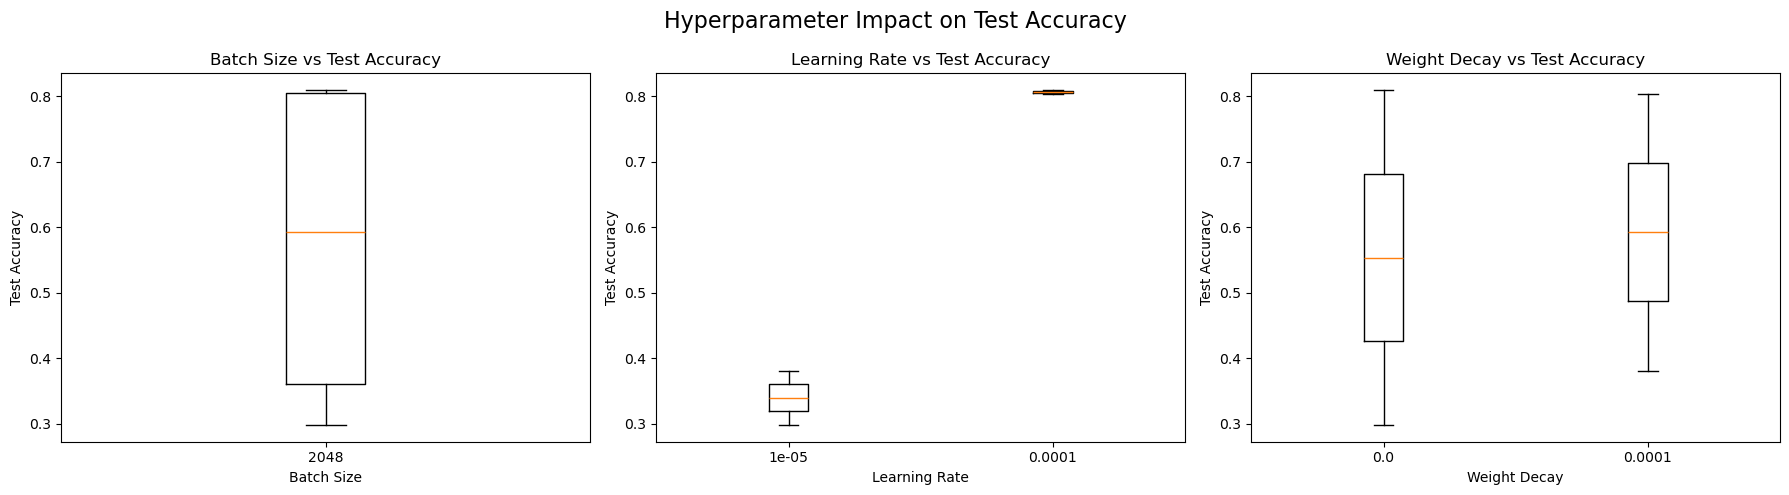

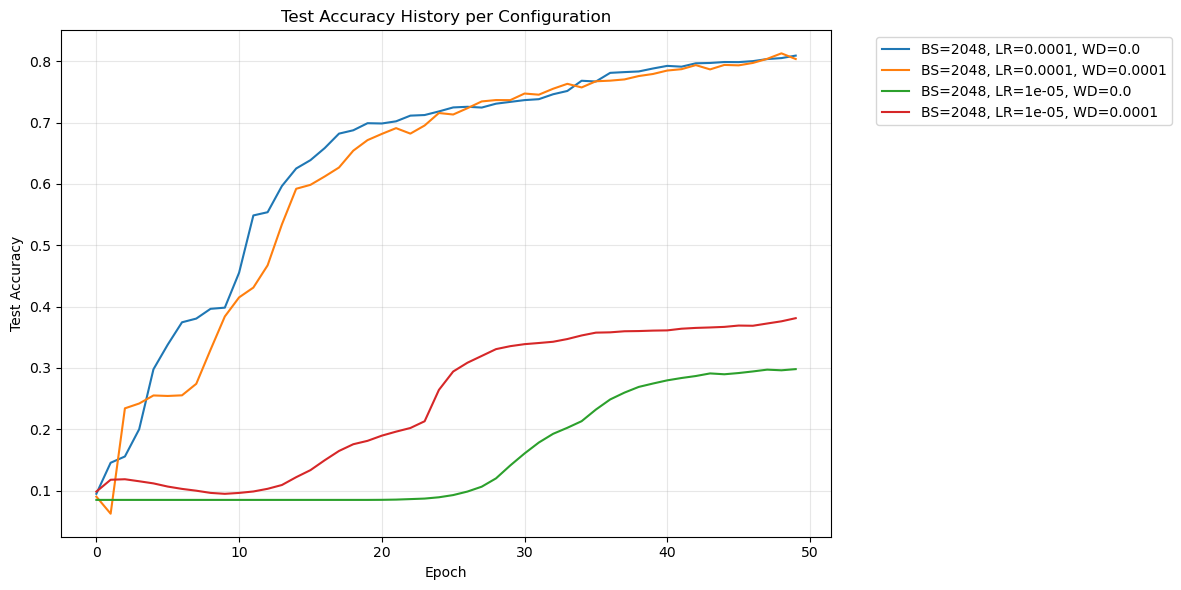

In [35]:
# Analyze Hyperparameter Tuning Results
results_df = pd.DataFrame([
    {
        'batch_size': res['config']['batch_size'],
        'lr': res['config']['lr'],
        'weight_decay': res['config']['weight_decay'],
        'final_test_acc': res['final_test_acc'],
        'final_test_loss': res['final_test_loss']
    }
    for res in experiment_results
])

# 1. Box Plots for each Hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hyperparameter Impact on Test Accuracy', fontsize=16)

# Batch Size
batch_sizes = sorted(results_df['batch_size'].unique())
axes[0].boxplot([results_df[results_df['batch_size'] == bs]['final_test_acc'] for bs in batch_sizes],
                labels=batch_sizes)
axes[0].set_title('Batch Size vs Test Accuracy')
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Test Accuracy')

# Learning Rate
lrs = sorted(results_df['lr'].unique())
axes[1].boxplot([results_df[results_df['lr'] == lr]['final_test_acc'] for lr in lrs],
                labels=lrs)
axes[1].set_title('Learning Rate vs Test Accuracy')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Test Accuracy')

# Weight Decay
wds = sorted(results_df['weight_decay'].unique())
axes[2].boxplot([results_df[results_df['weight_decay'] == wd]['final_test_acc'] for wd in wds],
                labels=wds)
axes[2].set_title('Weight Decay vs Test Accuracy')
axes[2].set_xlabel('Weight Decay')
axes[2].set_ylabel('Test Accuracy')

plt.tight_layout()
plt.show()

# 2. Training History Comparison
plt.figure(figsize=(12, 6))
for res in experiment_results:
    config_str = f"BS={res['config']['batch_size']}, LR={res['config']['lr']}, WD={res['config']['weight_decay']}"
    plt.plot(res['history']['test_acc'], label=config_str)

plt.title('Test Accuracy History per Configuration')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

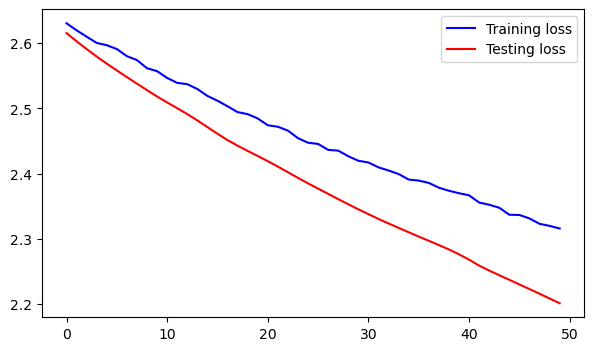

In [37]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(training_loss)), training_loss, linestyle='-', color='blue', label='Training loss')
plt.plot(np.arange(len(testing_loss)), testing_loss, linestyle='-', color='red', label='Testing loss')
plt.legend()
plt.show()

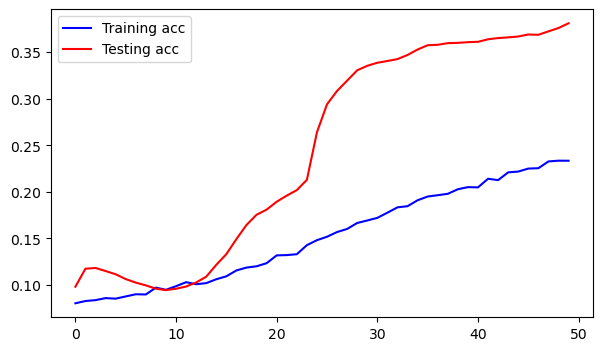

In [38]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(training_acc)), training_acc, linestyle='-', color='blue', label='Training acc')
plt.plot(np.arange(len(testing_acc)), testing_acc, linestyle='-', color='red', label='Testing acc')
plt.legend()
plt.show()

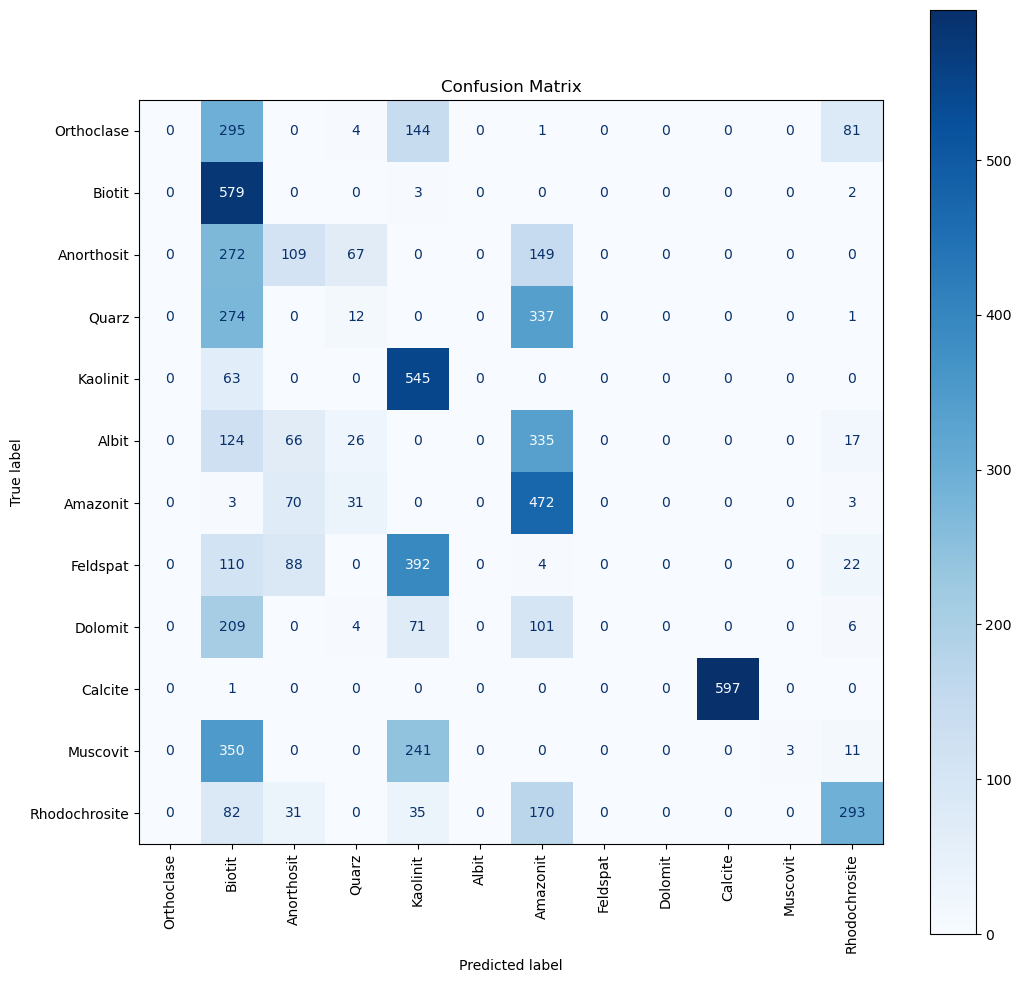

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions for the test set
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(y_batch.squeeze().tolist())
        y_pred.extend(predicted.tolist())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

In [40]:
# Select best config
if 'experiment_results' in locals() and experiment_results:
    best_result = max(experiment_results, key=lambda x: x['final_test_acc'])
    best_config = best_result['config']
    print(f"Best Config: {best_config} with Acc: {best_result['final_test_acc']:.4f}")

    # Retrain with best config
    print("Retraining best model for saving...")
    # Ensure dataset is available
    if 'X_train' in locals() and 'y_train' in locals():
        full_train_dataset = RockDataset(X_train, y_train)
        train_loader = DataLoader(full_train_dataset, batch_size=best_config['batch_size'], shuffle=True)
        
        # Re-initialize model
        model = Model()
        optimizer = torch.optim.Adam(params=model.parameters(), lr=best_config['lr'], weight_decay=best_config['weight_decay'])
        criterion = nn.CrossEntropyLoss()

        for epoch in range(best_config['epochs']):
            model.train()
            for X_batch, y_batch in train_loader:
                y_batch = y_batch.squeeze().long()
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
        print("Retraining complete.")

        # Save
        import json
        torch.save(model.state_dict(), 'mineral_classifier_cnn.pth')
        with open('class_names_cnn.json', 'w') as f:
            json.dump(class_names, f)
        print("Saved mineral_classifier_cnn.pth and class_names_cnn.json")
    else:
        print("Training data not found. Please run the data loading and splitting cells.")
else:
    print("No experiment results found. Please run the training loop.")

Best Config: {'batch_size': 2048, 'lr': 0.0001, 'epochs': 50, 'weight_decay': 0.0} with Acc: 0.8092
Retraining best model for saving...
Retraining complete.
Saved mineral_classifier_cnn.pth and class_names_cnn.json
